In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [ ]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

Chart 1: A correlation heatmap showing the relationships between columns C, D, E, F, and G.


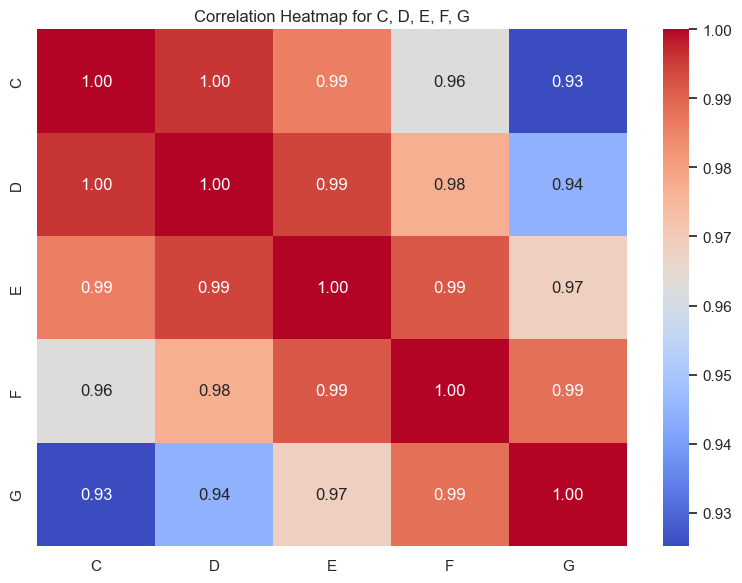

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation heatmap for columns 'C', 'D', 'E', 'F', 'G'
plt.figure(figsize=(8, 6))
correlation_matrix = df_raw[['C', 'D', 'E', 'F', 'G']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for C, D, E, F, G')
plt.tight_layout()
plt.show()
print("Chart 1: A correlation heatmap showing the relationships between columns C, D, E, F, and G.")

Chart 2: Histograms with KDE plots showing the distributions of highly skewed columns I, J, K, and L.


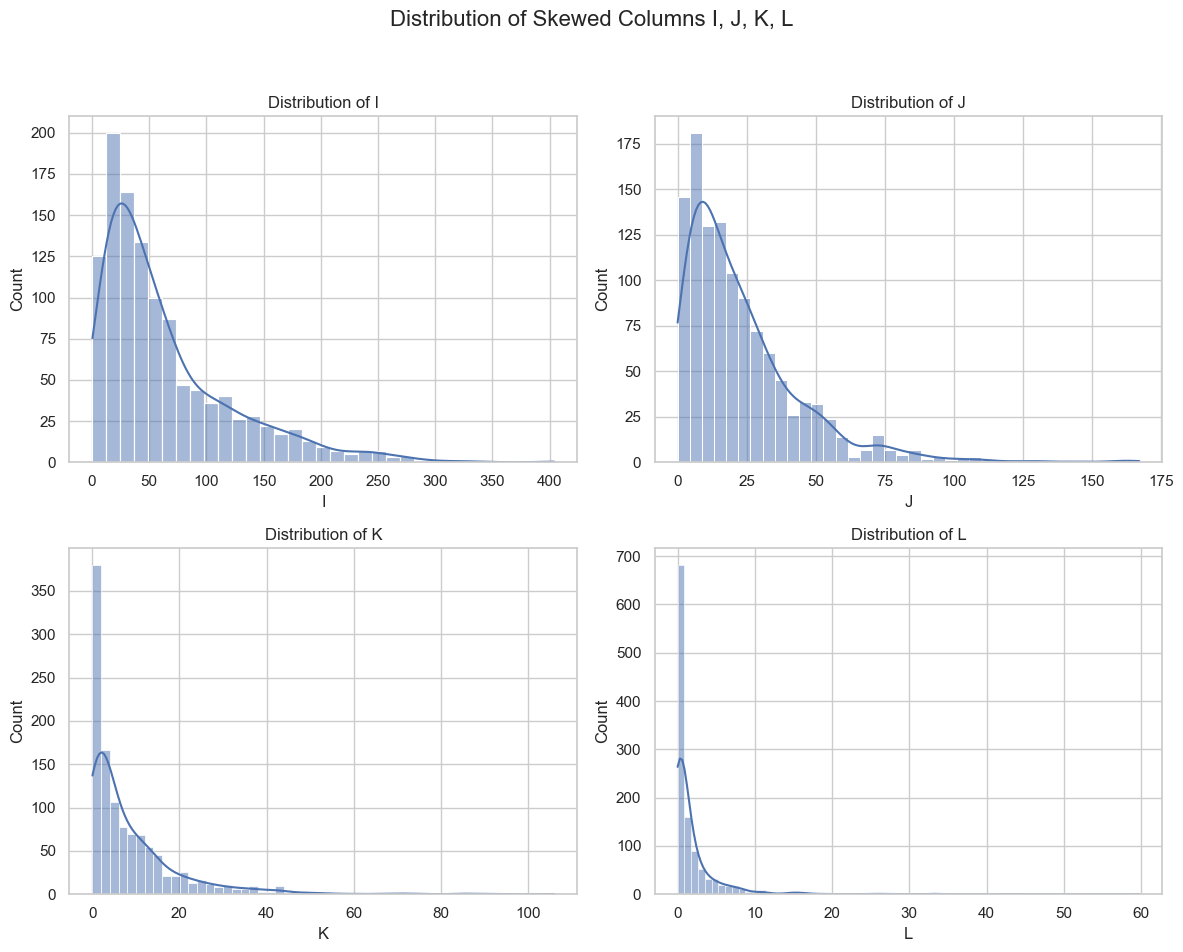

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Histograms/KDE plots for highly skewed columns 'I', 'J', 'K', 'L'
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Skewed Columns I, J, K, L', fontsize=16)

sns.histplot(df_raw['I'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of I')

sns.histplot(df_raw['J'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of J')

sns.histplot(df_raw['K'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of K')

sns.histplot(df_raw['L'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of L')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
print("Chart 2: Histograms with KDE plots showing the distributions of highly skewed columns I, J, K, and L.")

Chart 3: Count plots visualizing the distribution of values for binary and imbalanced columns A, B, S, and T.


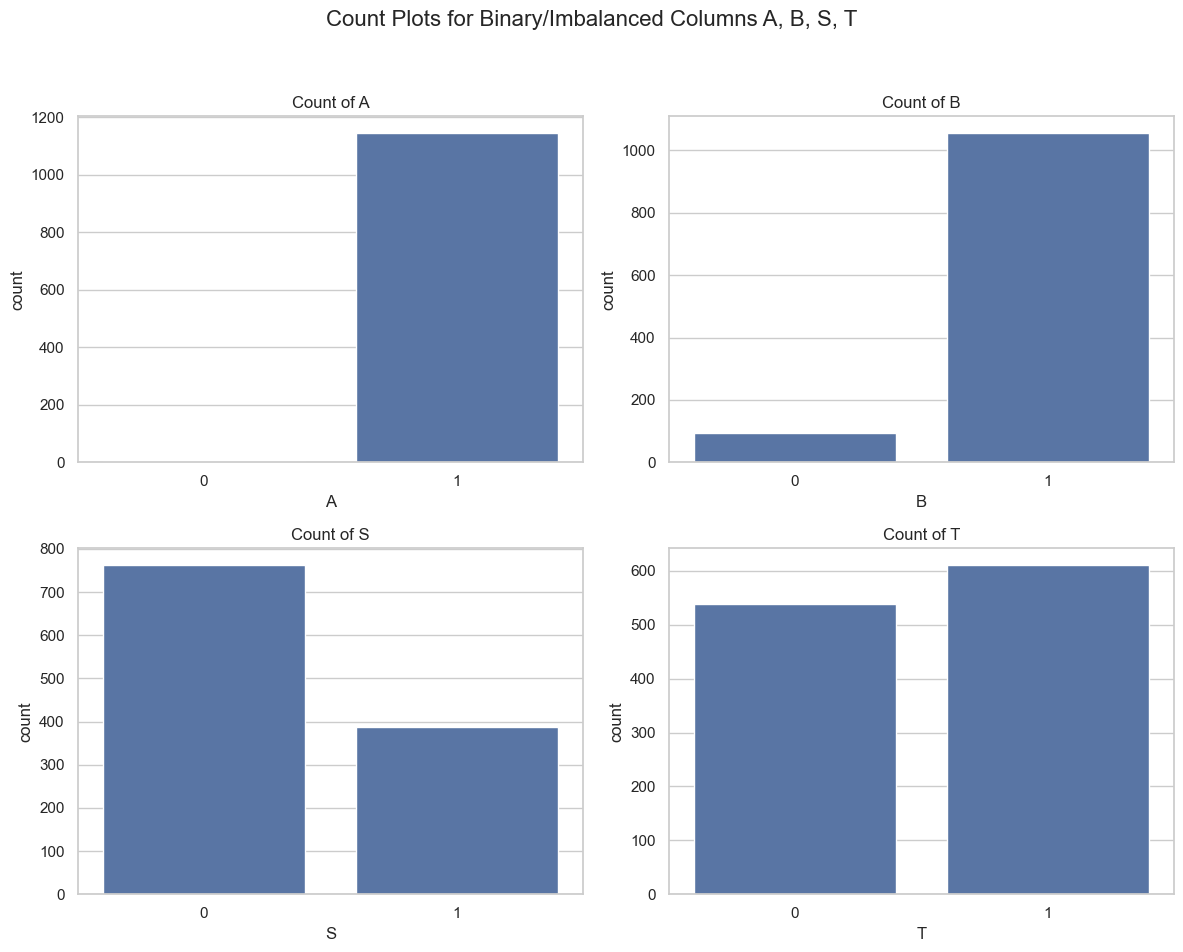

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Count plots for binary and imbalanced columns 'A', 'B', 'S', 'T'
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Count Plots for Binary/Imbalanced Columns A, B, S, T', fontsize=16)

sns.countplot(x=df_raw['A'], ax=axes[0, 0])
axes[0, 0].set_title('Count of A')

sns.countplot(x=df_raw['B'], ax=axes[0, 1])
axes[0, 1].set_title('Count of B')

sns.countplot(x=df_raw['S'], ax=axes[1, 0])
axes[1, 0].set_title('Count of S')

sns.countplot(x=df_raw['T'], ax=axes[1, 1])
axes[1, 1].set_title('Count of T')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Chart 3: Count plots visualizing the distribution of values for binary and imbalanced columns A, B, S, and T.")

Chart 4: Box plots showing the distribution and potential outliers in columns H and R.


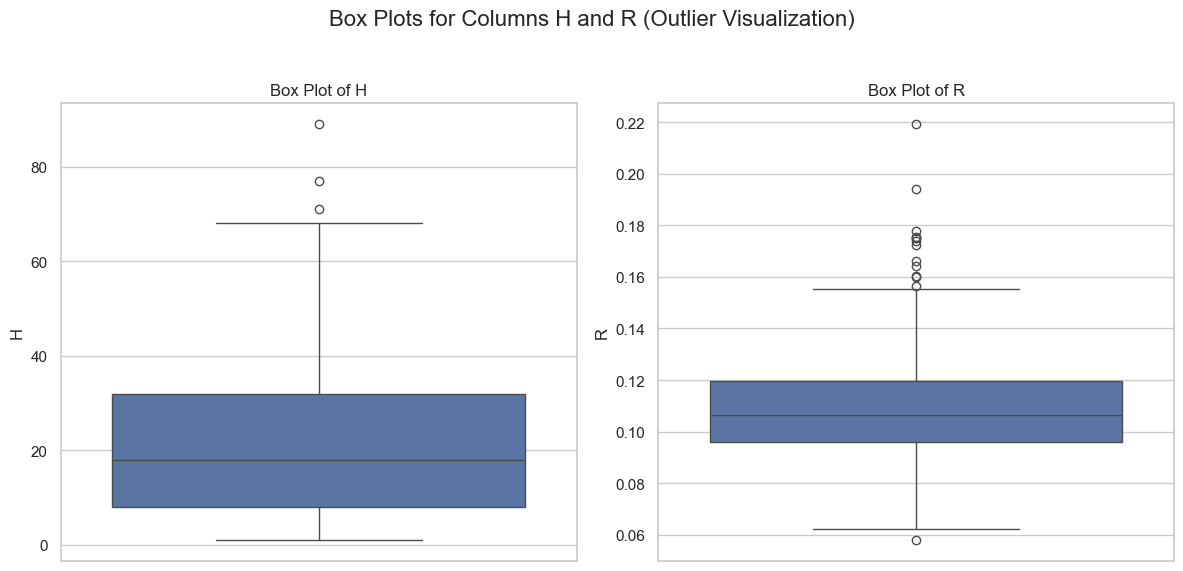

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Box plots for 'H' and 'R' to visualize detected outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Box Plots for Columns H and R (Outlier Visualization)', fontsize=16)

sns.boxplot(y=df_raw['H'], ax=axes[0])
axes[0].set_title('Box Plot of H')

sns.boxplot(y=df_raw['R'], ax=axes[1])
axes[1].set_title('Box Plot of R')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Chart 4: Box plots showing the distribution and potential outliers in columns H and R.")

This figure displays the distributions of columns M, N, O, and P using histograms with KDE plots. Each subplot shows the frequency and estimated probability density, revealing the skewness and range of values for each respective column.


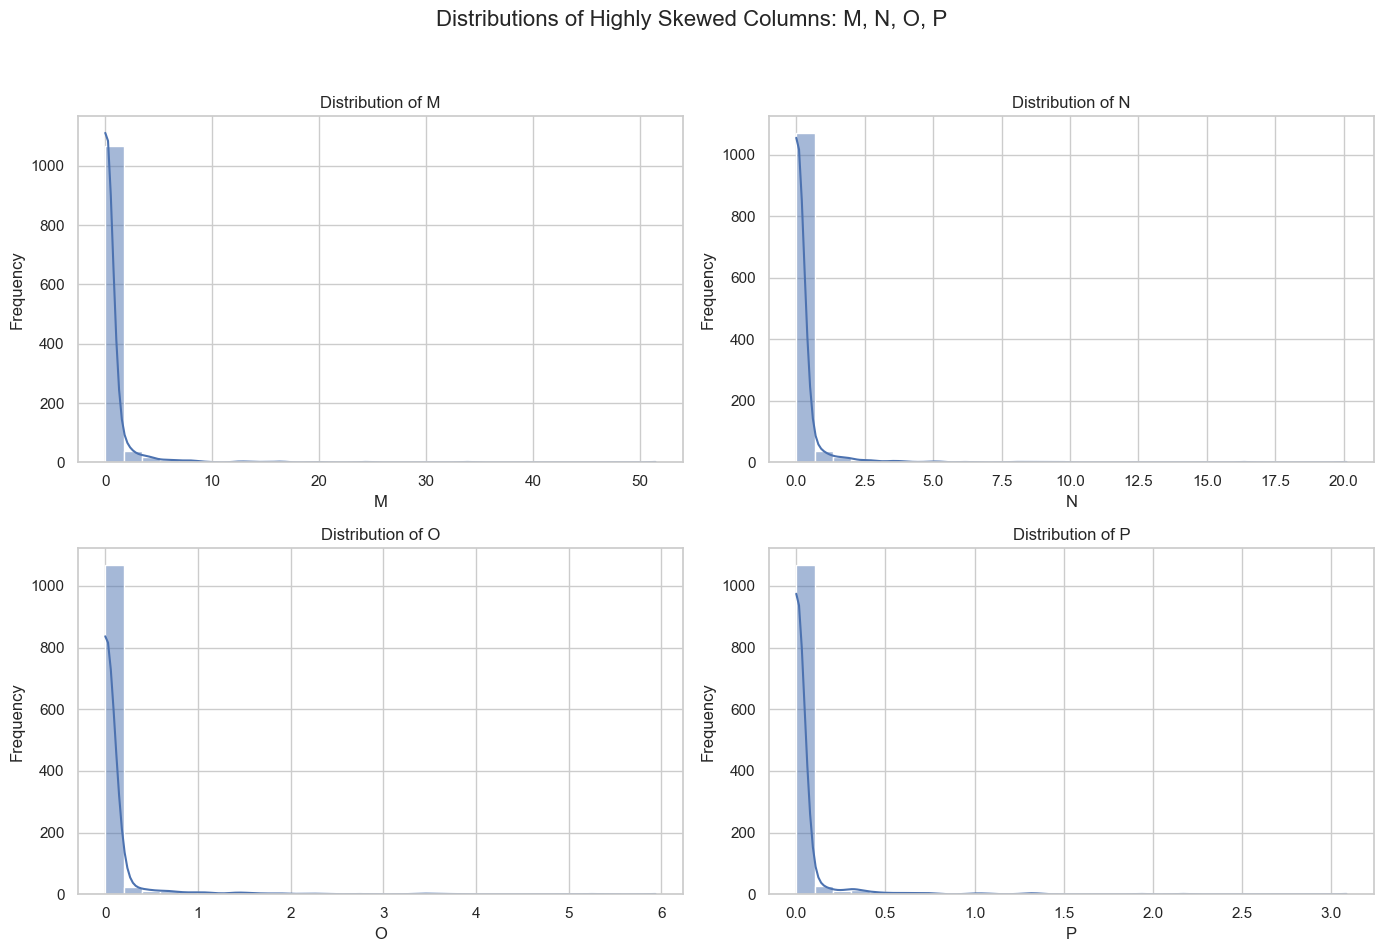

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2x2 subplots for the four highly skewed columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distributions of Highly Skewed Columns: M, N, O, P', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

columns_to_plot = ['M', 'N', 'O', 'P']

for i, col in enumerate(columns_to_plot):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

print("This figure displays the distributions of columns M, N, O, and P using histograms with KDE plots. Each subplot shows the frequency and estimated probability density, revealing the skewness and range of values for each respective column.")

This heatmap visualizes the pairwise correlations between columns C, D, E, F, and G, showing the strength and direction of linear relationships.


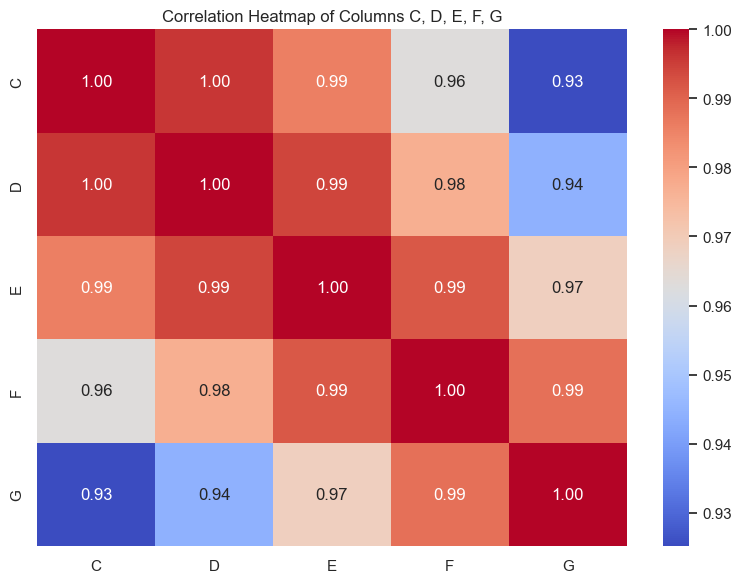

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Columns C, D, E, F, G')
plt.tight_layout()
plt.show()
print('This heatmap visualizes the pairwise correlations between columns C, D, E, F, and G, showing the strength and direction of linear relationships.')

These count plots display the frequency distribution of unique values for columns A and B, highlighting potential class imbalances.


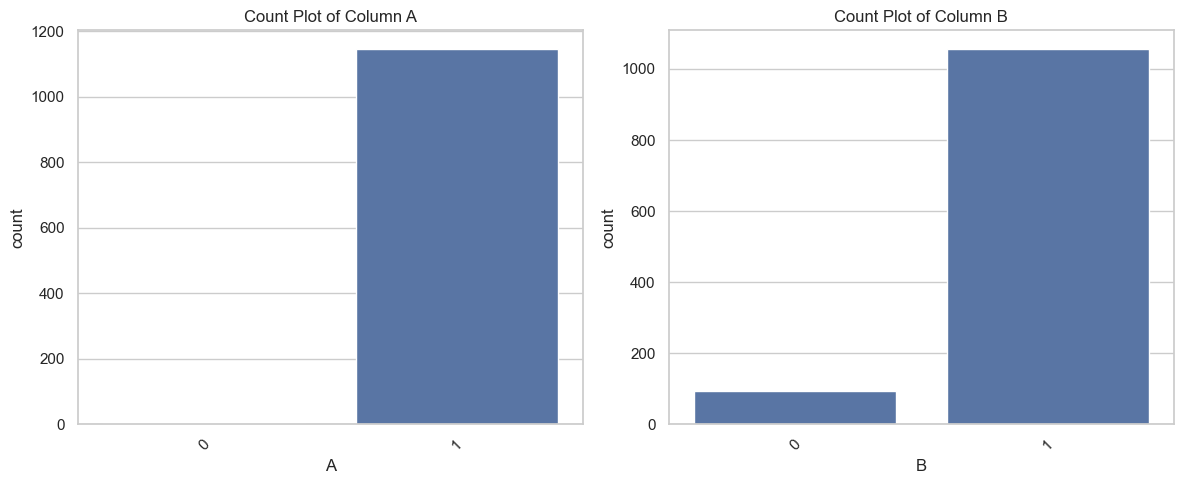

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='A', data=df_raw, ax=axes[0])
axes[0].set_title('Count Plot of Column A')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='B', data=df_raw, ax=axes[1])
axes[1].set_title('Count Plot of Column B')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('These count plots display the frequency distribution of unique values for columns A and B, highlighting potential class imbalances.')